In [1]:
import shutup; shutup.please()
import scanpy as sc
import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import KernelDensity
import os

# Set default figure size
plt.rcParams['figure.figsize'] = (12, 6)
PT_SIZE = 90
SAVE_MATRIX = True

In [7]:
var = pd.DataFrame(index=list(count.index), columns=["gene_name"])
var["gene_name"] = list(count.index)

In [8]:
meta = pd.read_excel("/home/lemgui01/CellExtractor/data/nano_geomx/Probe QC filtered.xlsx", sheet_name="SegmentProperties")
meta = meta[meta["SampleID"].str.contains("COVID")]

count = pd.read_excel("/home/lemgui01/CellExtractor/data/nano_geomx/Probe QC filtered.xlsx", sheet_name="TargetCountMatrix")
count.index = list(count["TargetName"])
count = count.drop(columns=["TargetName"])
count = count.loc[:, meta["SegmentDisplayName"]]

meta.index = list(count.columns)

var = pd.DataFrame(index=list(count.index), columns=["gene_name"])
var["gene_name"] = list(count.index)
adata = ad.AnnData(X=count.T, obs=meta, var=var)
# Remove problematic columns with all-NaN or non-string types before saving
# Here, 'QCFlags' and 'Origin Instrument ID' are all-NaN, which can cause issues
adata.obs = adata.obs.drop(columns=["QCFlags", "Origin Instrument ID"])

adata.write_h5ad("/home/lemgui01/CellExtractor/data/nano_geomx/covid_mk.h5ad")

In [9]:
adata

AnnData object with n_obs × n_vars = 36 × 19074
    obs: 'SlideName', 'ScanLabel', 'ROILabel', 'SegmentLabel', 'SegmentDisplayName', 'CD41+', 'AOISurfaceArea', 'AOINucleiCount', 'ROICoordinateX', 'ROICoordinateY', 'RawReads', 'AlignedReads', 'DeduplicatedReads', 'TrimmedReads', 'StitchedReads', 'SequencingSaturation', 'SequencingSetID', 'UMIQ30', 'RTSQ30', 'GeoMxNgsPipelineVersion', 'condition', 'LOT_Mouse_NGS_Whole_Transcriptome_Atlas_RNA_1_0', 'Type_1', 'Scan_ID_1', 'Disease_1', 'ROI_ID_1', 'SampleID_1', 'LOT_Mouse_NGS_Whole_Transcriptome_Atlas_RNA_1_1', 'Type_2', 'Scan_ID_2', 'condition_1', 'Disease_2', 'Type', 'ROI_ID_2', 'Disease', 'SampleID_2', 'SampleID', 'LOT_Mouse_NGS_Whole_Transcriptome_Atlas_RNA_1_2', 'ROIID', 'SegmentID', 'ScanWidth', 'ScanHeight', 'ScanOffsetX', 'ScanOffsetY', 'LOQ (Mouse NGS Whole Transcriptome Atlas RNA_1.0)', 'ExpressionFilteringThreshold (Mouse NGS Whole Transcriptome Atlas RNA_1.0)'
    var: 'gene_name'

In [ ]:
adata_harmonized = sc.read_h5ad("/home/lemgui01/CellExtractor/results_mk_/harmonized/Zeng_biorxiv_2023_12_26_573390.h5ad")
# adata_harmonized_park_fig1 = sc.read_h5ad("/home/lemgui01/CellExtractor/data/results_mk_112/harmonized/Park_science_science_aay322_fig1.h5ad")
# adata_harmonized_park_stem = sc.read_h5ad("/home/lemgui01/CellExtractor/data/results_mk_112/harmonized/Park_science_science_aay322_stem.h5ad")
# adata_harmonized = ad.concat([adata_harmonized_park_fig1, adata_harmonized_park_stem], label="study", keys=["Park_fig1", "Park_stem"], index_unique="-")

assign_genes = ["PPBP", "GP6", "PF4", "CD40LG", "FCGR2A", "GP1BA", "ITGB3", "ITGA2B"] # MK

# adata_harmonized.X = adata_harmonized.layers["raw"]

# sc.pp.normalize_total(adata_harmonized, target_sum=1e4)
# sc.pp.log1p(adata_harmonized)

# sc.tl.pca(adata_harmonized, n_comps=20, svd_solver="arpack")
# sc.pp.neighbors(adata_harmonized, n_pcs=20)
# sc.tl.umap(adata_harmonized)

In [4]:
adata_subset_genes = adata_harmonized[:, assign_genes]
mean_expr = adata_subset_genes.to_df().mean(axis=1)
adata_harmonized.obs["mean_expr"] = mean_expr

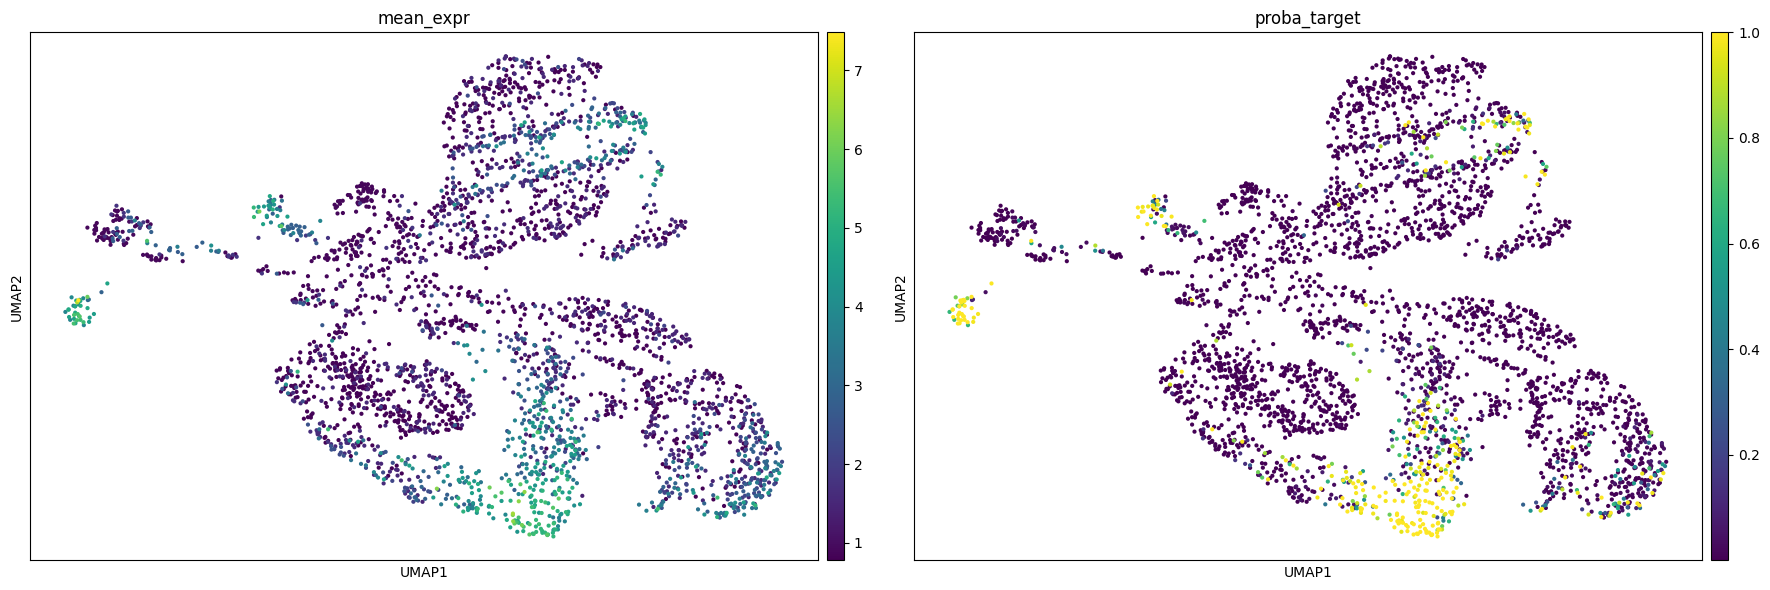

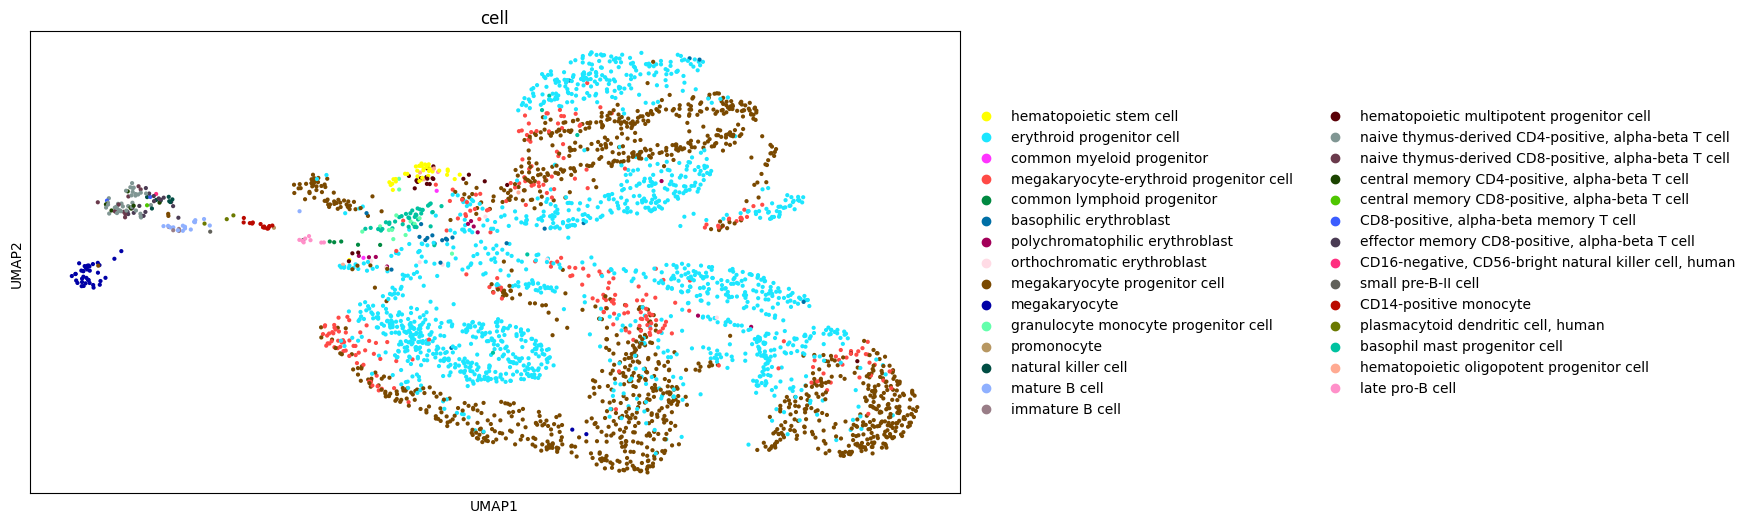

In [13]:
fig, axs = plt.subplots(1, 2, figsize=(18, 6))
sc.pl.umap(adata_harmonized, color="mean_expr", cmap="viridis", ax=axs[0], show=False)
sc.pl.umap(adata_harmonized, color="proba_target", cmap="viridis", ax=axs[1], show=False)
plt.tight_layout()

sc.pl.umap(adata_harmonized, color="cell", cmap="viridis")


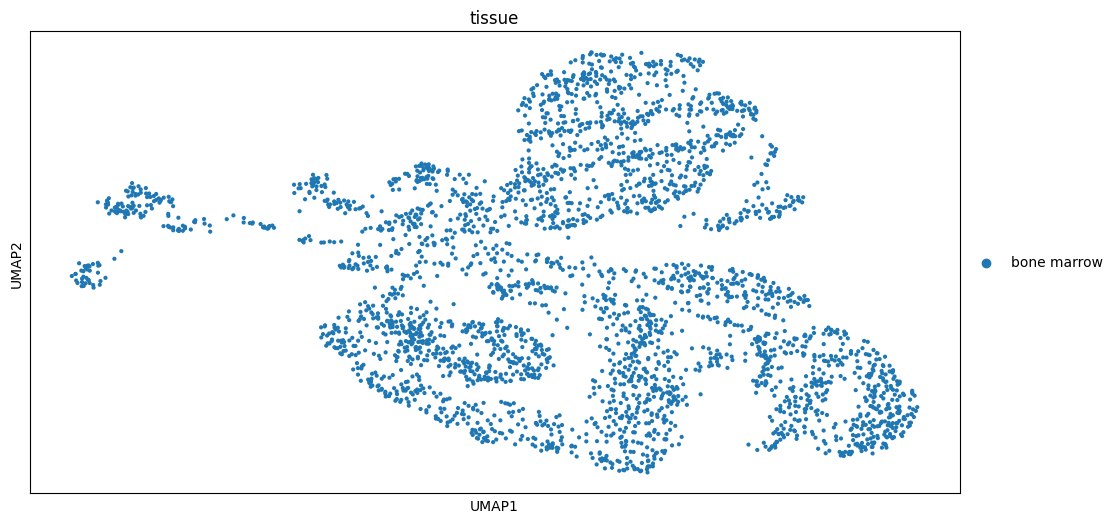

In [17]:
sc.pl.umap(adata_harmonized, color="tissue", cmap="viridis")